In [1]:
import pandas as pd
import numpy as np
from mplsoccer import VerticalPitch
import matplotlib.pyplot as plt
import unicodedata
from unidecode import unidecode

In [7]:
df_eng = pd.read_pickle('grids/bpl_2526_30_30.pkl')
df_eng['league'] = 'Premier League'
df_ita = pd.read_pickle('grids/seriea_2526_30_30.pkl')
df_ita['league'] = 'Serie A'
df_ger = pd.read_pickle('grids/bundes_2526_30_30.pkl')
df_ger['league'] = 'Bundesliga'
df = pd.concat([df_eng, df_ita, df_ger]).reset_index()
df = df.drop(columns=['index'])
df
df.to_pickle('grids/engitager_2526_30_30.pkl')

In [5]:
divmod(0, 5)
divmod(0, 5)

(0, 0)

In [10]:
matrix = ([[1,2],[3,4]])
for idx, x in np.ndenumerate(matrix):
    print(idx[0], idx[1], x)

0 0 1
0 1 2
1 0 3
1 1 4


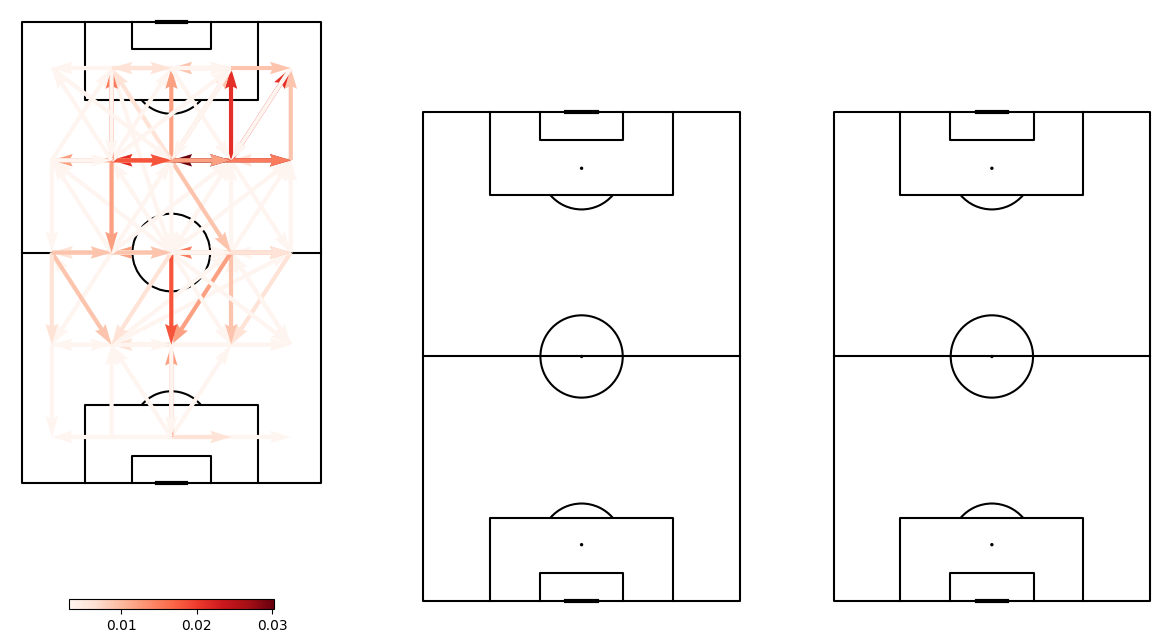

In [ ]:
df = pd.read_pickle('grids_movements/seriea_2526_5_5.pkl')
pitch = VerticalPitch(pitch_type='opta', line_color='black', pitch_color='white', linewidth=1.5)
fig, axes = plt.subplots(1, 3, figsize=(15, 9))
for ax in axes:
    pitch.draw(ax=ax)
grid = df.loc[0]['grid'].reshape((25,25))
xs = []
ys = []
xe = []
ye = []
percs = []
for idx, perc in np.ndenumerate(grid):
    state_start = idx[0]
    state_end = idx[1]
    x_start, y_start = divmod(state_start, 5)
    x_end, y_end = divmod(state_end, 5)
    if not (x_start==x_end and y_start==y_end):
        xs.append(x_start)
        ys.append(y_start)
        xe.append(x_end)
        ye.append(y_end)
        percs.append(perc)
    # print(state_start, state_end, (x_start, y_start), (x_end, y_end), perc)

new_df = pd.DataFrame()
new_df['x_start'] = xs
new_df['y_start'] = ys
new_df['x_end'] = xe
new_df['y_end'] = ye
new_df['perc'] = percs
new_df = new_df.loc[new_df['perc']>0]

pcm = pitch.arrows((new_df['x_start']*20)+10, (new_df['y_start']*20)+10, (new_df['x_end']*20)+10, (new_df['y_end']*20)+10, new_df['perc'], ax=axes[0],cmap='Reds', width=3)
fig.colorbar(pcm, ax=axes[0], shrink=0.6, orientation='horizontal')

In [5]:


df_hea = pd.read_pickle('grids/seriea_2526_30_30.pkl')
df_tou = pd.read_pickle('grids_movements/seriea_2526_10_10.pkl')
df_hea['player_name'] = df_hea['player_name'].apply(unidecode)
df_tou['player_name'] = df_tou['player_name'].apply(unidecode)
# pd.concat([df_hea, df_tou])
hea_tou = []
tou_hea = []
for i in df_hea.index:
    player_name = df_hea.loc[i]['player_name']
    player_df = df_tou.loc[df_tou['player_name'].str.lower() == player_name.lower()]
    if len(player_df) == 0:
        hea_tou.append(player_name)
        # print(f"{player_name} not present in grids_movements pickle")
for i in df_tou.index:
    player_name = df_tou.loc[i]['player_name']
    player_df = df_hea.loc[df_hea['player_name'].str.lower() == player_name.lower()]
    if len(player_df) == 0:
        tou_hea.append(player_name)
        # print(f"{player_name} not present in grids pickle")

print(sorted(hea_tou))
print(sorted(tou_hea))

['Anastasios Douvikas', 'Benjamin Dominguez', 'Ederson', 'Jean Daniel Akpa-Akpro', 'Joi Xheto Nuredini', 'Marc Kempf', 'Moatasem Al-Musrati']
['Al Musrati', 'Benja Dominguez', 'Ederson Silva', 'Jean-Daniel Akpa Akpro', 'Marc Oliver Kempf', 'Tasos Douvikas']


In [ ]:
filename_hea = 'top8_2526_30_30'
# df_hea = pd.read_pickle('grids/seriea_2526_30_30.pkl')
# df_hea = pd.read_pickle('grids/top8_2526_30_30.pkl')
df_hea = pd.read_pickle('grids/' + filename_hea + '.pkl')
filename_tou = 'bpl_2526_5_5'
# df_tou = pd.read_pickle('grids_movements/seriea_2526_5_5.pkl')
# df_tou = pd.read_pickle('grids_movements/seriea_2526_10_10.pkl')
# df_tou = pd.read_pickle('grids_movements/engitager_2526_10_10.pkl')
# df_tou = pd.read_pickle('grids_movements/engitager_2526_5_5.pkl')
df_tou = pd.read_pickle('grids_movements/' + filename_tou + '.pkl')


df_hea['player_name'] = df_hea['player_name'].apply(unidecode)
df_tou['player_name'] = df_tou['player_name'].apply(unidecode)



df_hea.loc[df_hea['player_name'] == 'Andreas Hanche Olsen', 'player_name'] = 'Andreas Hanche-Olsen'
df_hea.loc[df_hea['player_name'] == 'Ayoube Amaimouni Echghouyab', 'player_name'] = 'Ayoube Amaimouni-Echghouyab'
df_hea.loc[df_hea['player_name'] == 'David Daiber', 'player_name'] = 'David Santos'
df_hea.loc[df_hea['player_name'] == 'Ezequiel Fernandez', 'player_name'] = 'Equi Fernandez'
df_hea.loc[df_hea['player_name'] == 'Isak Hansen Aaroen', 'player_name'] = 'Isak Hansen-Aaroen'
df_hea.loc[df_hea['player_name'] == 'Jae-sung Lee', 'player_name'] = 'Lee Jae-Sung'
df_hea.loc[df_hea['player_name'] == 'Jonas Adjei Adjetey', 'player_name'] = 'Jonas Adjetey'
df_hea.loc[df_hea['player_name'] == 'Leart Paqarada', 'player_name'] = 'Leart Pacarada'







df_tou.loc[df_tou['player_name'] == 'Ameen Al Dakhil', 'player_name'] = 'Ameen Al-Dakhil'
df_tou.loc[df_tou['player_name'] == 'Dan-Axel Zagadou', 'player_name'] = 'Dan Zagadou'
df_tou.loc[df_tou['player_name'] == 'Daniel Heuer Fernandes', 'player_name'] = 'Daniel Fernandes'
df_tou.loc[df_tou['player_name'] == 'Niklas Beste', 'player_name'] = 'Jan-Niklas Beste'
df_tou.loc[df_tou['player_name'] == 'Dan Bentley', 'player_name'] = 'Daniel Bentley'
df_tou.loc[df_tou['player_name'] == 'Djiamgone Jocelin Ta Bi', 'player_name'] = 'Jocelin Ta Bi'
df_tou.loc[df_tou['player_name'] == 'Junior Kroupi', 'player_name'] = 'Eli Junior Kroupi'
df_tou.loc[df_tou['player_name'] == 'Florentino', 'player_name'] = 'Florentino Luis'
df_tou.loc[df_tou['player_name'] == 'Jair Cunha', 'player_name'] = 'Jair'
df_tou.loc[df_tou['player_name'] == 'Jamaldeen Jimoh-Aloba', 'player_name'] = 'Jamaldeen Jimoh'
df_tou.loc[df_tou['player_name'] == 'Josh King', 'player_name'] = 'Joshua King'
df_tou.loc[df_tou['player_name'] == 'Maximilian Kilman', 'player_name'] = 'Max Kilman'
df_tou.loc[df_tou['player_name'] == 'Ollie Scarles', 'player_name'] = 'Oliver Scarles'
df_tou.loc[df_tou['player_name'] == 'Vitalii Mykolenko', 'player_name'] = 'Vitaliy Mykolenko'



df_hea.to_pickle('grids/' + filename_hea + '.pkl')
df_tou.to_pickle('grids_movements/' + filename_tou + '.pkl')

In [6]:
df_tou = pd.read_pickle('grids_movements/seriea_2526_10_10.pkl')
df_tou.loc[df_tou['player_name'] == 'Tasos Douvikas', 'player_name'] = 'Anastasios Douvikas'
df_tou.loc[df_tou['player_name'] == 'Benja Dominguez', 'player_name'] = 'Benjamin Dominguez'
df_tou.loc[df_tou['player_name'] == 'Ederson Silva', 'player_name'] = 'Ederson'
df_tou.loc[df_tou['player_name'] == 'Jean-Daniel Akpa-Akpro', 'player_name'] = 'Jean Daniel Akpa-Akpro'
df_tou.loc[df_tou['player_name'] == 'Marc Oliver Kempf', 'player_name'] = 'Marc Kempf'
df_tou.loc[df_tou['player_name'] == 'Al Musrati', 'player_name'] = 'Moatasem Al-Musrati'
df_tou

,player_id,player_name,grid
0,302650.0,Gianluca Scamacca,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,129903.0,Mario Pasalic,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0006915629322..."
2,85070.0,Marten de Roon,"[0.0029225523623964927, 0.0014612761811982464,..."
3,454908.0,Isak Hien,"[0.0016168148746968471, 0.0, 0.002425222312045..."
4,405133.0,Giorgio Scalvini,"[0.00834597875569044, 0.010622154779969651, 0...."
...,...,...,...
462662,555393.0,Filippo Carbone,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
465253,141525.0,Nikita Contini,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
465399,602167.0,Tommaso Macchioni,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
465990,584400.0,Alessandro Cardinali,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [8]:
import numpy as np
import pandas as pd
pickle = pd.read_pickle('grids/top8_2526_30_30.pkl')
# pickle = pickle.loc[pickle['player_name'] == "Aaron Anselmino"]
pickle = pickle.loc[pickle['played_matches'] >= 10]

names = []
teams = []
grids = []
played_matches_arr = []
for i in pickle.index:
    row = pickle.loc[i]
    player_name = row['player_name']
    player_team = row['team']
    player_grid = row['grid']
    player_matches = row['played_matches']
    player_df = pickle.loc[pickle['player_name'] == player_name]
    if len(player_df)>1:
        # print(player_name)
        names.append(player_name)
        teams.append(player_team)
        grids.append(player_grid)
        played_matches_arr.append(player_matches)
names_df = pd.DataFrame()
names_df['name'] = names
names_df['team'] = teams
names_df['played_matches'] = played_matches_arr
names_df = names_df.sort_values(by=['name'])
# names_df.to_csv('utility/duplicates.csv')
names_df

,name,team,played_matches
35,Ademola Lookman,Atlético Madrid,12
6,Ademola Lookman,Atalanta,12
17,Alexsandro Amorim,Genoa,11
71,Alexsandro Amorim,FC Alverca,19
18,Alisson Santos,SSC Napoli,14
...,...,...,...
51,Vitinha,Paris Saint-Germain,29
49,Younes Namli,Le Havre,12
69,Younes Namli,PEC Zwolle,13
3,Zito Luvumbo,Cagliari,12


In [38]:
df = pd.read_pickle('grids/top8_2526_30_30.pkl')
df['player_name'] = df['player_name'].apply(unidecode)
player_name = "Cyril Ngonge"
player_team = "Torino"
df = df.loc[-((df['player_name'] == player_name) & (df['team'] == player_team))]
df.to_pickle('grids/top8_2526_30_30.pkl')

In [16]:
def find_alt_name(player_name):
    df = pd.read_csv('utility/alt_names.csv')
    player_df = df.loc[df['name'] == player_name]
    if len(player_df) == 0:
        player_df = df.loc[df['alt_name'] == player_name]
        if len(player_df) == 0:
            raise ValueError(f"Alternative name for player {player_name} not found!")
        else:
            row = player_df.iloc[0]
            alt_name = row['name']
    else:
        row = player_df.iloc[0]
        alt_name = row['alt_name']
    return alt_name

import pandas as pd
from unidecode import unidecode
df = pd.read_csv('utility/duplicates.csv')
pickle = pd.read_pickle('grids/top8_2526_30_30.pkl')
pickle['player_name'] = pickle['player_name'].apply(unidecode)
played_matches_arr = []

for i in df.index:
    row = df.loc[i]
    player_name = row['name']
    player_team = row['team']
    # print(player_name, player_team)
    player_df = pickle.loc[(pickle['player_name'].str.lower() == player_name.lower()) & (pickle['team'].str.lower() == player_team.lower())]
    if len(player_df) == 0:
            alt_name = find_alt_name(player_name=player_name)
            player_df = pickle.loc[(pickle['player_name'].str.lower() == alt_name.lower()) & (pickle['team'].str.lower() == player_team.lower())]
            if len(player_df) == 0:
                raise ValueError(f"Player {player_name} not found!")
    player_row = player_df.iloc[0]
    played_matches = player_row['played_matches']
    played_matches_arr.append(played_matches)
df['played_matches'] = played_matches_arr
df = df.drop(columns=['Unnamed: 0'])
df = df.sort_values(by=['name'])
df['most_recent'] = None
df.to_csv('utility/duplicates.csv', index=False)

In [5]:
pickle

,player_id,player_name,grid,position,position_detailed,team,played_matches,league
0,98059,Nicola Leali,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.002, 0.0...",G,GK,Genoa,22,Serie A
1,1087514,Brooke Norton-Cuffy,"[0.001, 0.001, 0.003, 0.0, 0.002, 0.0, 0.0, 0....",D,RM,Genoa,27,Serie A
2,1068885,Alessandro Marcandalli,"[0.0, 0.001, 0.001, 0.002, 0.001, 0.001, 0.001...",D,CB,Genoa,32,Serie A
3,889785,Johan Vásquez,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",D,CB,Genoa,36,Serie A
4,797286,Aarón Martín,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",M,LM,Genoa,33,Serie A
...,...,...,...,...,...,...,...,...
4343,61123,Pedro Trigueira,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",G,GK,AVS - Futebol SAD,1,Liga Portugal
4344,1799243,Hugo Nunes,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",M,CDM,Vitória SC,1,Liga Portugal
4345,1195449,Joao Carvalho,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",G,GK,Sporting Braga,1,Liga Portugal
4346,2338038,Antonio Gil,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",M,M,Sporting Braga,1,Liga Portugal
